In [57]:
import pandas as pd
import numpy as np


In [58]:
data=pd.read_csv('initial_dataset.csv')

In [59]:
data.head()

,MerchantID,TransactionAmount,RefundAmount,ChargebackAmount,Category,Description
0,M100000,3739.22,0.00,0.0,Services,Digital marketing agency
1,M100000,2732.08,0.00,0.0,Services,Digital marketing agency
2,M100000,4640.87,0.00,0.0,Services,Digital marketing agency
3,M100000,3892.77,388.40,0.0,Services,Digital marketing agency
4,M100000,1171.72,67.27,0.0,Services,Digital marketing agency


In [60]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1215287 entries, 0 to 1215286
Data columns (total 6 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   MerchantID         1215287 non-null  str    
 1   TransactionAmount  1215287 non-null  float64
 2   RefundAmount       1215287 non-null  float64
 3   ChargebackAmount   1215287 non-null  float64
 4   Category           1215287 non-null  str    
 5   Description        1215287 non-null  str    
dtypes: float64(3), str(3)
memory usage: 55.6 MB


In [61]:
data.shape

(1215287, 6)

In [62]:
agg_df = data.groupby('MerchantID').agg({
    'TransactionAmount': ['count', 'sum'],
    'RefundAmount': 'sum',
    'ChargebackAmount': 'sum',
    'Category': 'first',
    'Description': 'first'
}).reset_index()

In [63]:
agg_df.columns = [
    'MerchantID',
    'TransactionCount',
    'TotalVolume',
    'TotalRefundAmount',
    'TotalChargebackAmount',
    'Category',
    'Description'
]

In [64]:
agg_df['RefundRate'] = agg_df['TotalRefundAmount'] / agg_df['TotalVolume']
agg_df['ChargebackRate'] = agg_df['TotalChargebackAmount'] / agg_df['TotalVolume']

In [65]:
data_new=agg_df.fillna(0, inplace=True)

In [66]:
data_new.shape

(90000, 9)

In [67]:
data_new.head()

,MerchantID,TransactionCount,TotalVolume,TotalRefundAmount,TotalChargebackAmount,Category,Description,RefundRate,ChargebackRate
0,M100000,12,31897.62,866.28,244.28,Services,Digital marketing agency,0.027158,0.007658
1,M100001,11,24311.91,245.00,163.26,Services,Digital marketing agency,0.010077,0.006715
2,M100002,9,26054.12,1054.77,987.36,Gaming,Online gaming platform,0.040484,0.037897
3,M100003,10,21504.80,0.00,2896.81,Gaming,Online gaming platform,0.000000,0.134705
4,M100004,8,20065.74,716.21,212.30,Services,Digital marketing agency,0.035693,0.010580


In [69]:
data_new.isna().sum()

MerchantID               0
TransactionCount         0
TotalVolume              0
TotalRefundAmount        0
TotalChargebackAmount    0
Category                 0
Description              0
RefundRate               0
ChargebackRate           0
dtype: int64

                  TransactionCount  TotalVolume  RefundRate  ChargebackRate
TransactionCount          1.000000     0.891871   -0.000680       -0.002673
TotalVolume               0.891871     1.000000   -0.001313       -0.004859
RefundRate               -0.000680    -0.001313    1.000000        0.177804
ChargebackRate           -0.002673    -0.004859    0.177804        1.000000


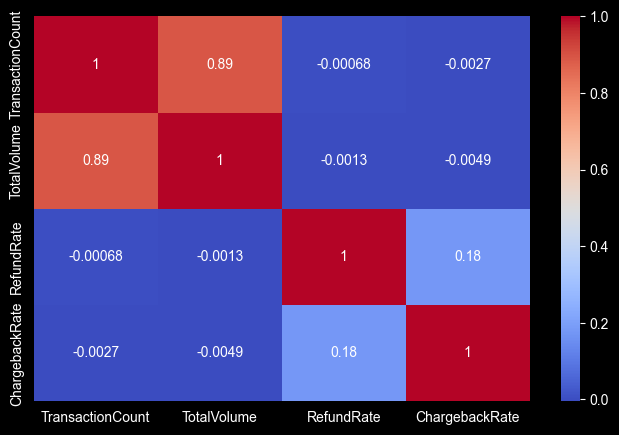

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
num_cols = ['TransactionCount', 'TotalVolume', 'RefundRate', 'ChargebackRate']

# Correlation matrix
corr = data_new[num_cols].corr()

print(corr)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [71]:
# Keep a copy
merchant_ids = data_new['MerchantID']

# Drop for ML
final_df = data_new.drop(columns=['MerchantID', 'Description'])

In [72]:
final_df = pd.get_dummies(final_df, columns=['Category'], drop_first=True)

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(final_df)

# Convert back to DataFrame (optional)
scaled_df = pd.DataFrame(scaled_data, columns=final_df.columns)

In [74]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)

scaled_df['Anomaly'] = model.fit_predict(scaled_df)

In [75]:
final_df['Anomaly'] = scaled_df['Anomaly']

In [76]:
risky_merchants = final_df[final_df['Anomaly'] == -1]

print(risky_merchants.head())
print("Total risky merchants:", len(risky_merchants))

    TransactionCount  TotalVolume  TotalRefundAmount  TotalChargebackAmount  \
3                 10     21504.80               0.00                2896.81   
13                14     33454.77            2489.72                 914.08   
24                19     44153.14            2892.17                3935.83   
46                18     47377.65             199.39                3964.49   
57                 8     17532.99              82.75                2243.24   

    RefundRate  ChargebackRate  Category_E-commerce  Category_Gaming  \
3     0.000000        0.134705                False             True   
13    0.074420        0.027323                False            False   
24    0.065503        0.089140                False             True   
46    0.004209        0.083678                False             True   
57    0.004720        0.127944                False            False   

    Category_Services  Category_Travel  Anomaly  
3               False            False    

In [77]:
final_df['Anomaly'].value_counts()

Anomaly
 1    85500
-1     4500
Name: count, dtype: int64

In [78]:
risky_merchants.sort_values(by='RefundRate', ascending=False).head()

,TransactionCount,TotalVolume,TotalRefundAmount,TotalChargebackAmount,RefundRate,ChargebackRate,Category_E-commerce,Category_Gaming,Category_Services,Category_Travel,Anomaly
40902,8,15239.94,2490.57,780.03,0.163424,0.051183,False,False,False,False,-1
25176,7,15441.44,2361.22,2036.26,0.152914,0.131870,False,True,False,False,-1
43836,8,18744.32,2782.39,1989.71,0.148439,0.106150,False,True,False,False,-1
31339,7,16884.82,2412.64,2192.40,0.142888,0.129844,False,True,False,False,-1
81937,7,17286.80,2452.37,844.84,0.141864,0.048872,False,False,False,False,-1


In [79]:
final_df['RiskScore'] = (
    final_df['RefundRate'] * 0.4 +
    final_df['ChargebackRate'] * 0.5 +
    (final_df['TransactionCount'] / final_df['TransactionCount'].max()) * 0.1
)

In [80]:
final_df['RiskScore'] = (final_df['RiskScore'] - final_df['RiskScore'].min()) / (
    final_df['RiskScore'].max() - final_df['RiskScore'].min()
)

In [81]:
def classify_risk(score):
    if score >= 0.7:
        return "High Risk"
    elif score >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

final_df['RiskLevel'] = final_df['RiskScore'].apply(classify_risk)

In [82]:
final_df['FinalRisk'] = final_df.apply(
    lambda x: "High Risk" if x['Anomaly'] == -1 else x['RiskLevel'],
    axis=1
)


In [84]:
final_df[['RiskScore', 'RiskLevel', 'FinalRisk']].head()

,RiskScore,RiskLevel,FinalRisk
0,0.258556,Low Risk,Low Risk
1,0.178409,Low Risk,Low Risk
2,0.294053,Low Risk,Low Risk
3,0.536444,Medium Risk,High Risk
4,0.160032,Low Risk,Low Risk


In [85]:
final_df['FinalRisk'].value_counts()

FinalRisk
Low Risk       43258
Medium Risk    38398
High Risk       8344
Name: count, dtype: int64

In [86]:
high_risk = final_df[final_df['FinalRisk'] == 'High Risk']

high_risk.sort_values(by='ChargebackRate', ascending=False).head(10)

,TransactionCount,TotalVolume,TotalRefundAmount,TotalChargebackAmount,RefundRate,ChargebackRate,Category_E-commerce,Category_Gaming,Category_Services,Category_Travel,Anomaly,RiskScore,RiskLevel,FinalRisk
8021,12,30941.07,2407.26,5761.24,0.077801,0.186200,False,False,False,False,-1,0.972022,High Risk,High Risk
73014,9,25921.67,1187.62,4557.15,0.045816,0.175805,False,True,False,False,-1,0.757111,High Risk,High Risk
20227,9,20413.89,130.08,3440.78,0.006372,0.168551,False,False,False,False,-1,0.630712,Medium Risk,High Risk
64750,7,12488.03,505.29,2104.81,0.040462,0.168546,False,True,False,False,-1,0.654381,Medium Risk,High Risk
11016,7,9998.93,22.24,1683.76,0.002224,0.168394,False,False,False,False,-1,0.554254,Medium Risk,High Risk
51459,7,14122.32,523.15,2360.77,0.037044,0.167166,False,True,False,False,-1,0.640980,Medium Risk,High Risk
88068,7,11660.11,841.04,1938.25,0.072130,0.166229,False,False,False,False,-1,0.729348,High Risk,High Risk
6016,7,17773.42,734.05,2941.94,0.041300,0.165525,False,True,False,False,-1,0.646725,Medium Risk,High Risk
2185,8,20701.15,429.45,3404.77,0.020745,0.164473,False,False,False,False,-1,0.622309,Medium Risk,High Risk
47831,7,15744.64,675.22,2588.49,0.042886,0.164405,False,False,False,False,-1,0.647207,Medium Risk,High Risk


In [87]:
final_df.head(20)

,TransactionCount,TotalVolume,TotalRefundAmount,TotalChargebackAmount,RefundRate,ChargebackRate,Category_E-commerce,Category_Gaming,Category_Services,Category_Travel,Anomaly,RiskScore,RiskLevel,FinalRisk
0,12,31897.62,866.28,244.28,0.027158,0.007658,False,False,True,False,1,0.258556,Low Risk,Low Risk
1,11,24311.91,245.00,163.26,0.010077,0.006715,False,False,True,False,1,0.178409,Low Risk,Low Risk
2,9,26054.12,1054.77,987.36,0.040484,0.037897,False,True,False,False,1,0.294053,Low Risk,Low Risk
3,10,21504.80,0.00,2896.81,0.000000,0.134705,False,True,False,False,-1,0.536444,Medium Risk,High Risk
4,8,20065.74,716.21,212.30,0.035693,0.010580,False,False,True,False,1,0.160032,Low Risk,Low Risk
5,16,47604.76,1247.49,85.56,0.026205,0.001797,False,False,True,False,1,0.367263,Low Risk,Low Risk
6,14,32804.74,2410.65,1599.97,0.073485,0.048773,False,True,False,False,1,0.578313,Medium Risk,Medium Risk
7,12,27870.44,834.63,126.32,0.029947,0.004532,False,False,True,False,1,0.255641,Low Risk,Low Risk
8,15,31715.25,830.54,1546.91,0.026187,0.048775,False,False,False,False,1,0.487653,Medium Risk,Medium Risk
9,15,52751.22,1303.09,229.14,0.024703,0.004344,False,False,True,False,1,0.339072,Low Risk,Low Risk


In [88]:
def explain(row):
    reasons = []

    if row['ChargebackRate'] > 0.2:
        reasons.append("High chargeback rate")
    if row['RefundRate'] > 0.15:
        reasons.append("High refund rate")
    if row['TransactionCount'] > 200:
        reasons.append("High transaction activity")

    return ", ".join(reasons)

high_risk['Reason'] = high_risk.apply(explain, axis=1)

In [89]:
high_risk[['FinalRisk', 'Reason']].head(10)

,FinalRisk,Reason
3,High Risk,
13,High Risk,
24,High Risk,
35,High Risk,
46,High Risk,
47,High Risk,
57,High Risk,
65,High Risk,
70,High Risk,
71,High Risk,
